In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("birajsth/cats-and-dogs-filtered")

print("Path to dataset files:", path)

100%|██████████| 131M/131M [00:00<00:00, 160MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/birajsth/cats-and-dogs-filtered/versions/1


Contents of dataset: ['dogs', 'cats']
Total cat images found: 1000
Total dog images found: 1000


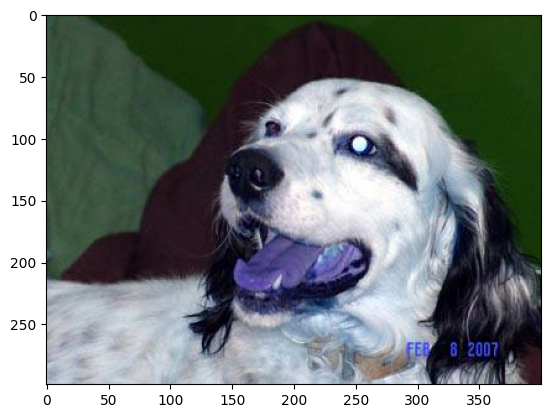

In [22]:
#AI written code
import glob
import os
import cv2
import matplotlib.pyplot as plt

# 1. Point to the train directory
train_dir = os.path.join(path, "cats_and_dogs_filtered", "train")

# Check subdirectories (classes)
print("Contents of dataset:", os.listdir(train_dir))

# 2. Get one image path from the 'cats' directory
cat_images = glob.glob(os.path.join(train_dir, "cats", "*.jpg"))
print(f"Total cat images found: {len(cat_images)}")


#same thing we will do for dogs
dog_images = glob.glob(os.path.join(train_dir, "dogs", "*.jpg"))
print(f"Total dog images found: {len(dog_images)}")

img_bgr=cv2.imread(cat_images[0])
img_dog=cv2.imread(dog_images[0])
plt.imshow(img_dog)



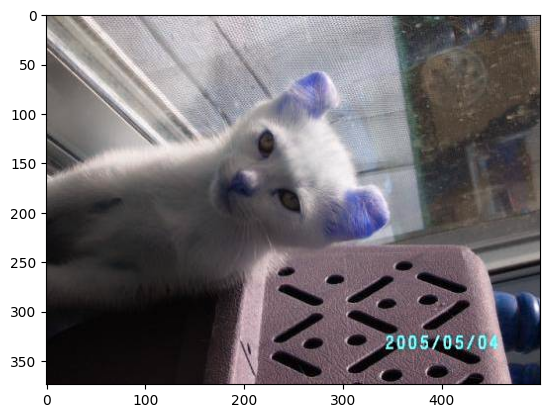

In [20]:
plt.imshow(img_bgr)

In [24]:
# so basically blue tint kyu ho rha hai ,maine opencv(bgr) and  amtplotlib(rgb)
cat_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
dog_rgb = cv2.cvtColor(img_dog, cv2.COLOR_BGR2RGB)


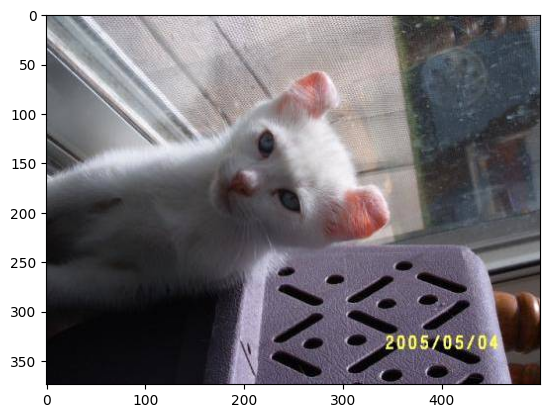

In [26]:
plt.imshow(cat_rgb)

In [28]:
import glob
import os
import cv2
import numpy as np
sample_paths = cat_images[:50] + dog_images[:50]

shapes = []
means = []
stds = []

for p in sample_paths:
  img = cv2.imread(p)
  img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0

  shapes.append(img_rgb.shape)
  # Mean per channel (R, G, B)
  means.append(img_rgb.mean(axis=(0, 1)))
   # Std per channel (R, G, B)
  stds.append(img_rgb.std(axis=(0, 1)))

# Aggregate results
unique_shapes = set(shapes)
global_mean = np.mean(means, axis=0)
global_std = np.mean(stds, axis=0)

print(f"Sampled Image Shapes (H, W, C): {list(unique_shapes)[:3]} ...")
print(f"Channel Means (R, G, B): {global_mean}")
print(f"Channel Stds  (R, G, B): {global_std}")

Sampled Image Shapes (H, W, C): [(377, 500, 3), (444, 499, 3), (231, 299, 3)] ...
Channel Means (R, G, B): [0.48445759 0.44630809 0.4066599 ]
Channel Stds  (R, G, B): [0.22668256 0.22084502 0.21791258]
